# Start-up: CalorIA

## Pipeline del trabajo

<p align="center">
  <img src="pipeline_arquitectura.excalidraw.svg" alt="Pipeline de IA Nutricional" width="90%">
</p>

## Librerías

In [1]:
import sys
print(sys.executable)

/home/javier/miniconda3/envs/tf_gpu/bin/python


In [ ]:
from food_description import FoodNutritionSystem
from user_profile import UserProfile
from nutrition_lookup import lookup_dish, analyze_meal, print_meal_summary

import json
from datetime import datetime
import os
from IPython.display import display
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/home/javier/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# EJECUTAR SOLO UNA VEZ: carga el modelo en GPU
nutrition_system = FoodNutritionSystem(unload_text_model=True)

Loading Vision Model: Qwen/Qwen2-VL-7B-Instruct on cuda...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 730/730 [00:18<00:00, 39.76it/s] 


System initialized.


## Crear el usuario

In [ ]:
# ─── Configura aquí tu perfil ────────────────────────────────
user = UserProfile(
    name           = "Usuario",
    sex            = "male",        # "male" | "female"
    age            = 25,
    weight_kg      = 75.0,
    height_cm      = 178.0,
    activity_level = 3,             # entrenos/semana (0-6)
    goal           = "maintenance"  # "loss" | "maintenance" | "gain"
)

print(user.summary())

# Guardar en user.json con el mismo formato que espera el resto del notebook
with open("user.json", "w") as f:
    json.dump({
        "name": user.name,
        "daily_targets": {
            "kcal":      user.daily_targets["kcal"],
            "protein_g": user.daily_targets["protein"],
            "carbs_g":   user.daily_targets["carbs"],
            "fat_g":     user.daily_targets["fat"],
        }
    }, f, indent=4)

=== Usuario | Mantenimiento ===
BMR: 1742 kcal  |  TDEE: 2701 kcal
Objetivo diario: 2701 kcal
  Proteína: 135g
  Carbos:   351g
  Grasa:    84g


## Estimar alimentos y cantidades

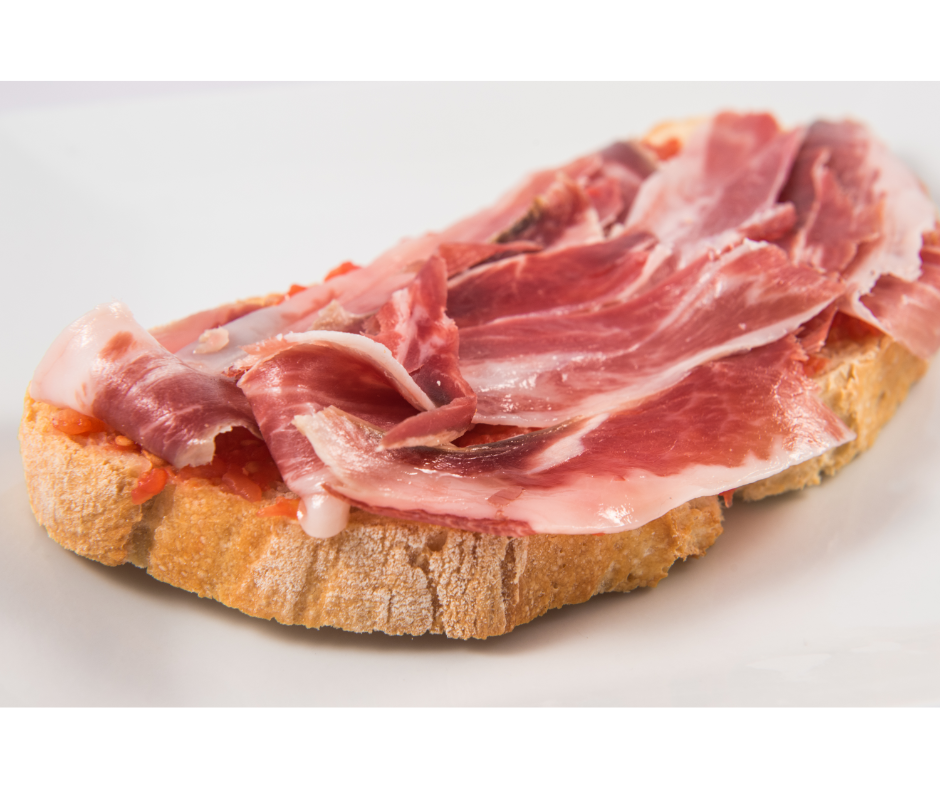

Loading Text Model: Qwen/Qwen2.5-3B-Instruct on cuda...


Loading weights: 100%|██████████| 434/434 [00:02<00:00, 203.95it/s]


Refining user input: 'Tostada de Jamón, desayuno español'...
Refined context: '"Ham tostada, breakfast dish"'
Unloading Text Model from VRAM...
Analyzing image with Qwen2-VL...

Plato: Ham tostada (Confianza: high)


,name,grams,source
0,ham,50,visible
1,bread,20,visible
2,tomato,5,visible


In [ ]:
# Ruta de la imagen
img_path = "images/foto5.png" 
display(Image.open(img_path)) # Ver la foto

# Texto opcional del usuario
user_input = "Tostada de Jamón, desayuno español"
#user_input = None # O déjalo en None si no quieres añadir nada

# Ejecutar el análisis completo
resultado = nutrition_system.analyze_food(img_path, user_context_text=user_input)

# Mostrar resultados
if "ingredients" in resultado:
    print(f"\nPlato: {resultado['dish_name']} (Confianza: {resultado['confidence']})")
    df = pd.DataFrame(resultado['ingredients'])
    display(df)
else:
    print(resultado)

## Cálculo de macros y calorías

In [ ]:
## Lookup nutricional completo (plato → ingredientes → LLM)

if "ingredients" not in resultado:
    print("El detector no devolvió ingredientes válidos.")
    print(resultado)
else:
    dish_name   = resultado["dish_name"]
    total_grams = sum(ing["grams"] for ing in resultado["ingredients"])
    foods       = [{"name": ing["name"], "grams": ing["grams"]} for ing in resultado["ingredients"]]

    
# 1. Intentar lookup del plato completo (USDA → OpenFoodFacts)
    lookup_name = resultado.get("canonical_name") or dish_name

    dish_result = lookup_dish(
        lookup_name,
        total_grams,
        model=nutrition_system.v_model,
        processor=nutrition_system.v_processor
    )

    if dish_result:
        # Encontró el plato — mostrar directamente
        print(f"\n{'═'*58}")
        print(f"  RESUMEN NUTRICIONAL — {dish_result['name'].upper()}")
        print(f"  Fuente: {dish_result['source']}  |  Peso total: {dish_result['grams']}g")
        print(f"{'═'*58}")
        print(f"  Calorías:      {dish_result['kcal']} kcal")
        print(f"  Proteína:      {dish_result['protein_g']} g")
        print(f"  Carbohidratos: {dish_result['carbs_g']} g")
        print(f"  Grasa:         {dish_result['fat_g']} g")
        print(f"  Fibra:         {dish_result['fiber_g']} g")
        print(f"  Sodio:         {dish_result['sodium_mg']} mg")
        print(f"{'═'*58}\n")
    else:
        # Fallback: lookup ingrediente por ingrediente (USDA → OpenFoodFacts → LLM)
        nutrition = analyze_meal(
            foods,
            model=nutrition_system.v_model,
            processor=nutrition_system.v_processor
        )
        print_meal_summary(nutrition)


🍽️  Buscando plato completo: 'Grilled Salmon with Lemon and Herb Sauce' (486g)
  [USDA] Error en búsqueda de 'Grilled Salmon with Lemon and Herb Sauce': 429 Client Error: Too Many Requests for url: https://api.nal.usda.gov/fdc/v1/foods/search?query=Grilled+Salmon+with+Lemon+and+Herb+Sauce&api_key=DEMO_KEY&pageSize=5&dataType=Foundation%2CSR+Legacy
  [OFF] Error para 'Grilled Salmon with Lemon and Herb Sauce': 503 Server Error: Service Temporarily Unavailable for url: https://world.openfoodfacts.org/cgi/search.pl?search_terms=Grilled+Salmon+with+Lemon+and+Herb+Sauce&json=1&action=process&page_size=5&fields=product_name%2Cnutriments&sort_by=unique_scans_n
  → Plato 'Grilled Salmon with Lemon and Herb Sauce' no encontrado. Entrando en lookup por ingredientes.

Buscando: 'grilled salmon' (200g)
  [USDA] Error en búsqueda de 'grilled salmon': 429 Client Error: Too Many Requests for url: https://api.nal.usda.gov/fdc/v1/foods/search?query=grilled+salmon&api_key=DEMO_KEY&pageSize=5&dataType=F

## Guardar datos

In [7]:
def save_meal(data, filename="meals.json"):
    now = datetime.now()
    date_str = now.strftime("%Y-%m-%d")
    time_str = now.strftime("%H:%M:%S")

    # Añadir hora al registro
    data["time"] = time_str

    # Cargar archivo existente
    if os.path.exists(filename):
        with open(filename, "r") as f:
            db = json.load(f)
    else:
        db = {}

    # Si no existe el día, crearlo
    if date_str not in db:
        db[date_str] = []

    # Añadir comida
    db[date_str].append(data)

    # Guardar
    with open(filename, "w") as f:
        json.dump(db, f, indent=4)

    print(f"Guardado en {date_str} a las {time_str}")

save_meal({
    "dish_name": dish_name,
    "ingredients": foods,
    "nutrition": dish_result if dish_result else nutrition
})

Guardado en 2026-03-24 a las 21:15:57


## Resumen diario

In [9]:
def get_daily_summary(date, meals_file="meals.json", user_file="user.json"):

    with open(meals_file, "r") as f:
        meals_db = json.load(f)

    with open(user_file, "r") as f:
        user = json.load(f)

    meals = meals_db.get(date, [])

    total = {
        "kcal": 0,
        "protein_g": 0,
        "carbs_g": 0,
        "fat_g": 0
    }

    for meal in meals:
        nutr = meal["nutrition"]["totals"]

        total["kcal"] += nutr.get("kcal", 0)
        total["protein_g"] += nutr.get("protein_g", 0)
        total["carbs_g"] += nutr.get("carbs_g", 0)
        total["fat_g"] += nutr.get("fat_g", 0)

    targets = user["daily_targets"]

    return {
        "total": total,
        "targets": targets,
        "remaining": {
            key: targets[key] - total[key]
            for key in targets
        }
    }



In [10]:
summary =get_daily_summary(date=datetime.now().strftime("%Y-%m-%d"),meals_file="meals.json", user_file="user.json")
summary 

{'total': {'kcal': 630.1, 'protein_g': 44.5, 'carbs_g': 32.5, 'fat_g': 29.9},
 'targets': {'kcal': 2701, 'protein_g': 135, 'carbs_g': 351, 'fat_g': 84},
 'remaining': {'kcal': 2070.9,
  'protein_g': 90.5,
  'carbs_g': 318.5,
  'fat_g': 54.1}}

In [ ]:
def compute_percentages(total, targets):
    percentages = {}

    for key in targets:
        if targets[key] > 0:
            percentages[key] = total[key] / targets[key]
        else:
            percentages[key] = 0

    return percentages



def plot_radar(percentages):
    labels = list(percentages.keys())
    values = list(percentages.values())

    # Cerrar el círculo
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    line_color = "#E07A5F"  
    fill_color = "#F2CC8F"   
    grid_color = "#EAE2D6"  

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    ax.spines["polar"].set_visible(False)

    ax.grid(color=grid_color, linewidth=1)

    # Plot principal
    ax.plot(angles, values, linewidth=2.5, color=line_color)
    ax.fill(angles, values, color=fill_color, alpha=0.6)

    # Etiquetas
    pretty_labels = {
        "kcal": "Calories",
        "protein_g": "Protein",
        "carbs_g": "Carbs",
        "fat_g": "Fat"
    }

    display_labels = [pretty_labels.get(l, l) for l in labels]

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(display_labels, fontsize=11)

    # Límites
    ax.set_ylim(0, 1.5)

    ax.plot(angles, [1]*len(angles), linestyle="dashed", linewidth=2, color="#81B29A")
    ax.text(0, 1.05, "Target", color="#81B29A", fontsize=10)

    ax.set_yticklabels([])

    # Título
    plt.title("Daily Nutrition Balance (%)", fontsize=14, weight="bold", pad=20)

    plt.show()

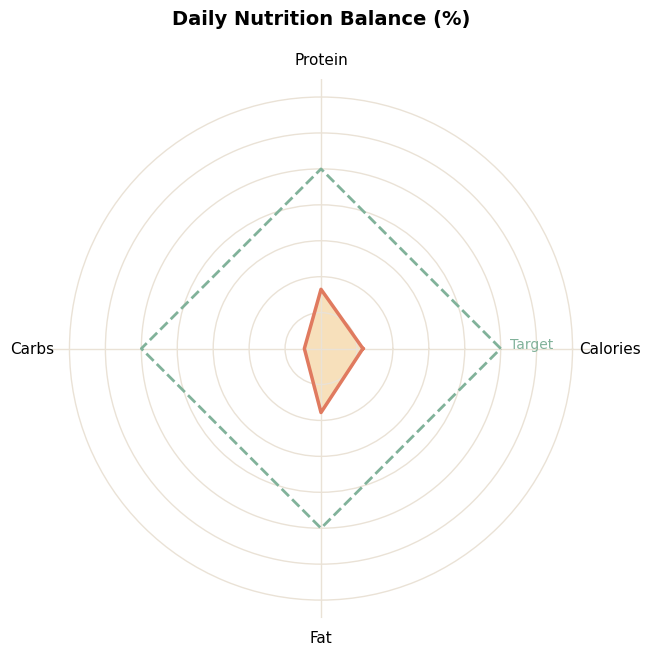

In [12]:
percentages = compute_percentages(
    summary["total"],
    summary["targets"]
)

plot_radar(percentages)